# 03 · Real CASALS waveform analysis

This notebook inspects a bounded, explicit sample of the 2024-11-18 L1B H5: sweeps 5000–5002, 256 tracks per sweep, and 2,728 RX bins. The package detector writes the component and pulse tables; plots then use those outputs and selected raw waveform records. A detected component is a waveform feature, not a confirmed physical return. The official geolocation remains the per-pulse refh point.

## Paths and detector settings

The detector settings come from the supported package API. No algorithm is reimplemented in this notebook.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
from IPython.display import display
from casals_l1b.peaks_cli import default_config, extract_components, build_detector_config
from casals_l1b.waveform import (
    build_record_index_grid, read_sweep_matrix, preprocess_waveform,
    detect_candidate_components_1d, classify_prominent_components,
)

ROOT = Path.cwd()
if not (ROOT / "casals_l1b").is_dir():
    raise RuntimeError("Run this notebook from the CASALS repository root.")
H5_PATH = ROOT / "data/raw/casals_l1b/casals_l1b_20241118T171757_001_02.h5"
SWEEPS = [5000, 5001, 5002]
OUTPUT_ROOT = ROOT / "outputs/notebooks/03_waveform_analysis/peaks"
if not H5_PATH.exists():
    raise FileNotFoundError(f"Missing real CASALS H5 input: {H5_PATH}")
print("H5:", H5_PATH.relative_to(ROOT))
print("Sweeps:", SWEEPS)

H5: data\raw\casals_l1b\casals_l1b_20241118T171757_001_02.h5
Sweeps: [5000, 5001, 5002]


## Extract component features

The call reads only the selected sweep waveforms while retaining pulse/sweep/track associations from the full H5 record index.

In [2]:
run_config = default_config([H5_PATH], OUTPUT_ROOT)
extract_result = extract_components(H5_PATH, sweep_selection=SWEEPS,
                                    config=run_config, output_dir=OUTPUT_ROOT)
COMPONENT_PATH = Path(extract_result["component_table"])
PULSE_PATH = Path(extract_result["pulse_summary"])
SWEEP_PATH = Path(extract_result["sweep_summary"])
components = pd.read_parquet(COMPONENT_PATH)
pulses = pd.read_parquet(PULSE_PATH)
sweep_summary = pd.read_csv(SWEEP_PATH)
print(f"Selected pulses: {len(pulses):,}; component rows: {len(components):,}")
display(sweep_summary[["sweep_num", "n_valid_pulses", "median_refh_snr",
                       "median_n_candidate_components", "fraction_valid_secondary_peak",
                       "fixed_bin_mode", "fixed_bin_fraction", "continuity_p95_abs_residual"]])

H5: C:\Users\zhong267\OneDrive - purdue.edu\CASALS\data\raw\casals_l1b\casals_l1b_20241118T171757_001_02.h5
Output dir: C:\Users\zhong267\OneDrive - purdue.edu\CASALS\outputs\notebooks\03_waveform_analysis\peaks\casals_l1b_20241118T171757_001_02
Selected sweeps: [5000, 5001, 5002]


Processing sweep 5000: valid_tracks=256, missing_tracks=0


Finished sweep 5000: pulses=256, components=1034, median prominent=2.00


Processing sweep 5001: valid_tracks=256, missing_tracks=0


Finished sweep 5001: pulses=256, components=959, median prominent=1.00


Processing sweep 5002: valid_tracks=256, missing_tracks=0


Finished sweep 5002: pulses=256, components=1071, median prominent=2.00


Selected pulses: 768; component rows: 3,064


,sweep_num,n_valid_pulses,median_refh_snr,median_n_candidate_components,fraction_valid_secondary_peak,fixed_bin_mode,fixed_bin_fraction,continuity_p95_abs_residual
0,5000,256,3.838088,4.0,0.535156,1693.0,0.378906,375.5
1,5001,256,3.919184,3.0,0.468750,1693.0,0.352941,313.3
2,5002,256,3.645453,4.0,0.542969,1694.0,0.321569,761.2


## RX waveform matrix for one real sweep

Each row is a track and each column is an RX bin. Missing tracks, if any, stay as NaN rather than being filled with synthetic values.

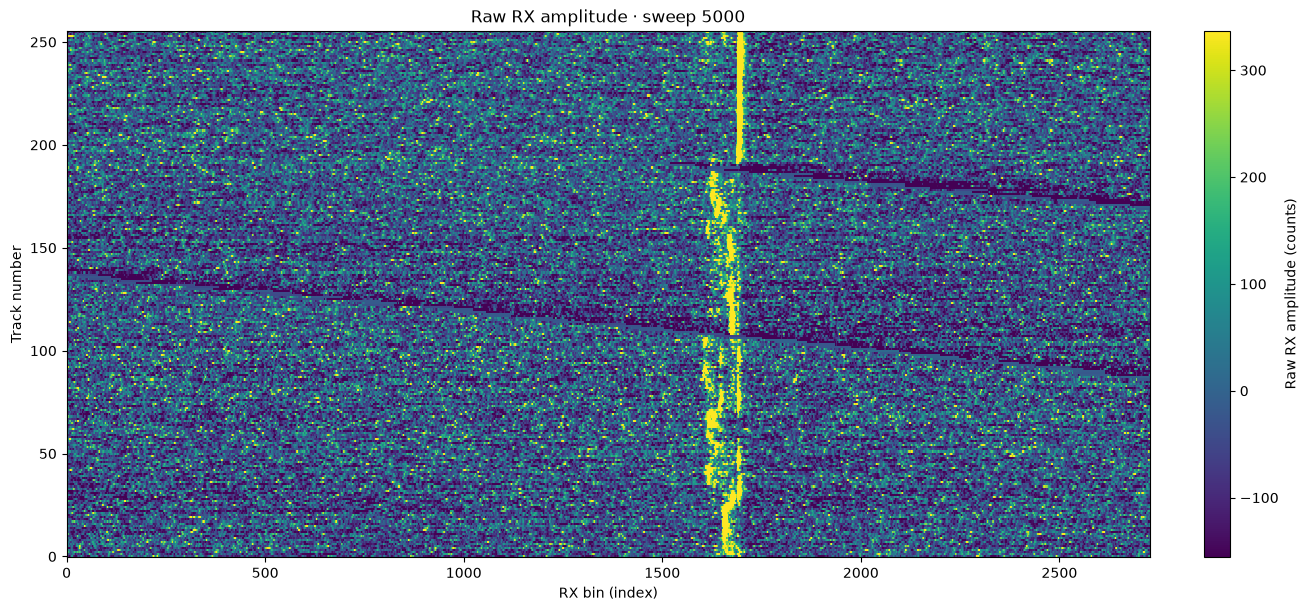

Tracks read: 256 / 256; RX bins: 2728


In [3]:
with h5py.File(H5_PATH, "r") as h5:
    index_info = build_record_index_grid(h5)
    rx_matrix, valid_tracks, record_indices = read_sweep_matrix(h5, "rx_waveform", 5000, index_info)
rx_bins = np.arange(rx_matrix.shape[1])
fig, ax = plt.subplots(figsize=(13, 6), constrained_layout=True)
im = ax.imshow(rx_matrix, aspect="auto", origin="lower", interpolation="nearest",
               extent=[rx_bins[0], rx_bins[-1], -0.5, rx_matrix.shape[0]-0.5],
               cmap="viridis", vmin=np.nanpercentile(rx_matrix, 5), vmax=np.nanpercentile(rx_matrix, 99))
ax.set(xlabel="RX bin (index)", ylabel="Track number", title="Raw RX amplitude · sweep 5000")
fig.colorbar(im, ax=ax, label="Raw RX amplitude (counts)")
plt.show()
print(f"Tracks read: {len(valid_tracks)} / {index_info.n_tracks}; RX bins: {rx_matrix.shape[1]}")

## One pulse: raw, background-corrected waveform, and detected components

The selected pulse is sweep 5000 / track 214, a real detector case with both accepted secondary components and rejected low-prominence components. The full window and main-peak neighborhood are shown separately.

pulse_index=1,280,218; refh_snr=6.814; raw argmax bin=1694; component rows=6


,component_rank,peak_bin,amplitude_raw,prominence,width_bins,is_main_component,is_valid_secondary_candidate,rejected_reason
908,1,1693.0,1850.0,1861.26605,7.537777,True,False,
909,2,2548.0,532.0,543.897436,5.67413,False,True,
910,3,747.0,482.0,491.557933,6.216253,False,True,
911,4,150.0,392.0,405.606131,7.903697,False,False,low_absolute_prominence
912,5,1461.0,377.0,380.927126,9.477885,False,False,low_absolute_prominence
913,6,1106.0,358.0,377.653171,7.925479,False,False,low_absolute_prominence


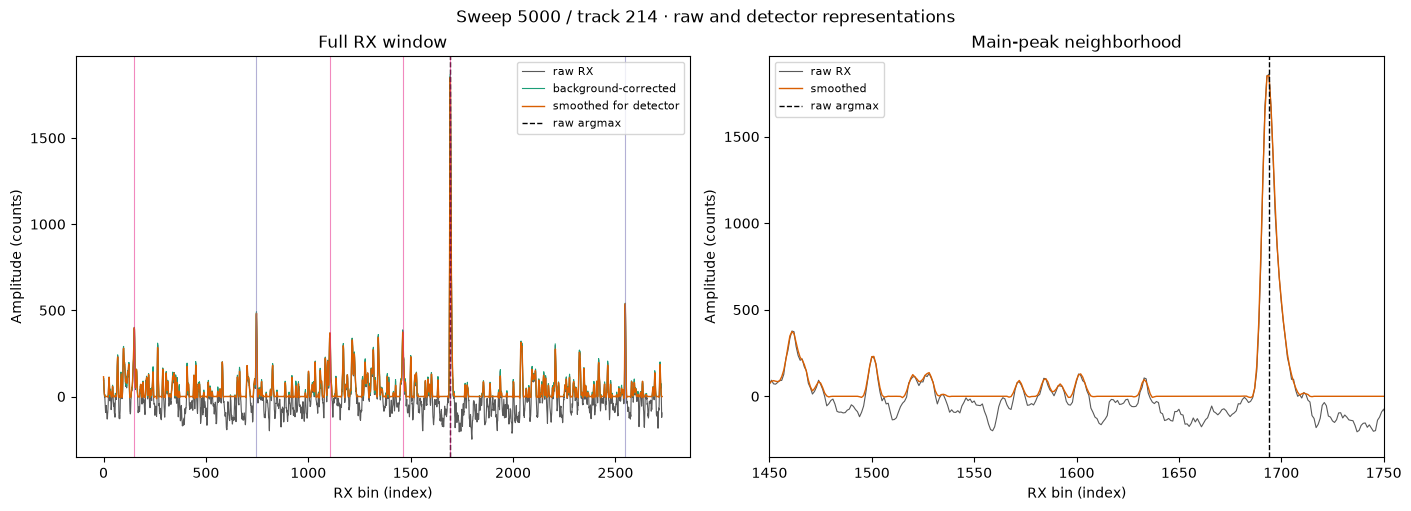

In [4]:
TARGET_SWEEP, TARGET_TRACK = 5000, 214
target_pulse_index = int(index_info.record_index_grid[TARGET_SWEEP, TARGET_TRACK])
if target_pulse_index < 0:
    raise RuntimeError("The explicitly selected real pulse is absent from the H5 record grid.")
with h5py.File(H5_PATH, "r") as h5:
    y_raw = np.asarray(h5["rx_waveform"][target_pulse_index], dtype=np.float64)
    bg_mean = float(h5["bg_mean"][target_pulse_index])
    bg_std = float(h5["bg_std"][target_pulse_index])
    refh_thres = float(h5["refh_thres"][target_pulse_index])
    refh_snr = float(h5["refh_snr"][target_pulse_index])
    raw_argmax_bin = int(np.argmax(y_raw))

detector_cfg = build_detector_config(run_config)
prepared = preprocess_waveform(y_raw, bg_mean, bg_std, refh_thres, detector_cfg)
detected = classify_prominent_components(
    detect_candidate_components_1d(y_raw, bg_mean, bg_std, refh_thres, detector_cfg), detector_cfg)
target_components = components[components.pulse_index == target_pulse_index].sort_values("component_rank")
print(f"pulse_index={target_pulse_index:,}; refh_snr={refh_snr:.3f}; raw argmax bin={raw_argmax_bin}; "
      f"component rows={len(target_components)}")
display(target_components[["component_rank", "peak_bin", "amplitude_raw", "prominence",
                           "width_bins", "is_main_component", "is_valid_secondary_candidate",
                           "rejected_reason"]])

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
bins = np.arange(y_raw.size)
axes[0].plot(bins, y_raw, color="0.35", lw=.8, label="raw RX")
axes[0].plot(bins, prepared["processed"], color="#1b9e77", lw=.8, label="background-corrected")
axes[0].plot(bins, prepared["smoothed"], color="#d95f02", lw=1.0, label="smoothed for detector")
axes[0].axvline(raw_argmax_bin, color="black", linestyle="--", lw=1, label="raw argmax")
for _, row in target_components.iterrows():
    axes[0].axvline(row.peak_bin, color="#7570b3" if row.is_valid_secondary_candidate else "#e7298a",
                    alpha=.55, lw=.8)
axes[0].set(xlabel="RX bin (index)", ylabel="Amplitude (counts)", title="Full RX window")
axes[0].legend(fontsize=8)
axes[1].plot(bins, y_raw, color="0.35", lw=.8, label="raw RX")
axes[1].plot(bins, prepared["smoothed"], color="#d95f02", lw=1.0, label="smoothed")
axes[1].axvline(raw_argmax_bin, color="black", linestyle="--", lw=1, label="raw argmax")
axes[1].set_xlim(1450, 1750)
axes[1].set(xlabel="RX bin (index)", ylabel="Amplitude (counts)", title="Main-peak neighborhood")
axes[1].legend(fontsize=8)
fig.suptitle("Sweep 5000 / track 214 · raw and detector representations")
plt.show()

## Component population and refh quality

These summaries describe detector output and pulse-level diagnostics. A secondary-component rate is not a return count. The SNR relationship is descriptive, not a causal or independent accuracy test.

,sweep_num,component_role,components
0,5000,accepted secondary,214
1,5000,main,256
2,5000,rejected candidate,564
3,5001,accepted secondary,183
4,5001,main,255
5,5001,rejected candidate,521
6,5002,accepted secondary,225
7,5002,main,255
8,5002,rejected candidate,591


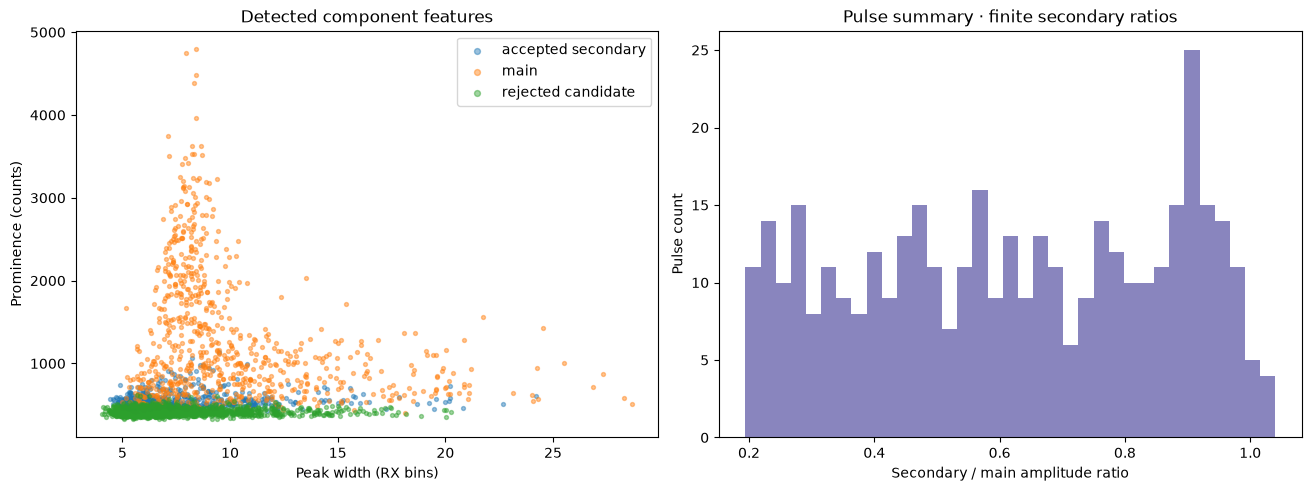

,snr_band,pulses,valid_secondary_rate,median_candidates
0,"(-0.001, 1.0]",0,<NA>,<NA>
1,"(1.0, 2.0]",61,0.196721,3.0
2,"(2.0, 3.0]",199,0.613065,5.0
3,"(3.0, 4.0]",144,0.666667,4.0
4,"(4.0, 5.0]",88,0.670455,4.0
5,"(5.0, 7.0]",120,0.541667,4.0
6,"(7.0, 12.0]",142,0.295775,3.0


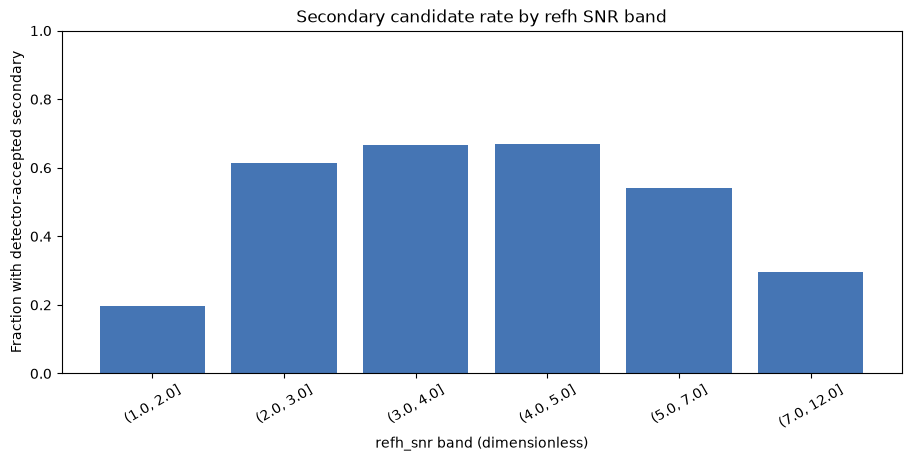

In [5]:
components["component_role"] = np.select(
    [components["is_main_component"].astype(bool), components["is_valid_secondary_candidate"].astype(bool)],
    ["main", "accepted secondary"], default="rejected candidate")
component_counts = components.groupby(["sweep_num", "component_role"]).size().rename("components").reset_index()
display(component_counts)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)
for role, group in components.groupby("component_role"):
    axes[0].scatter(group["width_bins"].to_numpy(dtype=float, na_value=np.nan),
                    group["prominence"].to_numpy(dtype=float, na_value=np.nan),
                    s=8, alpha=.45, label=role)
axes[0].set(xlabel="Peak width (RX bins)", ylabel="Prominence (counts)", title="Detected component features")
axes[0].legend(markerscale=1.5)
secondary_ratio = pulses["secondary_to_main_amp_ratio"].to_numpy(dtype=float, na_value=np.nan)
axes[1].hist(secondary_ratio[np.isfinite(secondary_ratio)], bins=35, color="#7570b3", alpha=.85)
axes[1].set(xlabel="Secondary / main amplitude ratio", ylabel="Pulse count",
            title="Pulse summary · finite secondary ratios")
plt.show()

snr_bins = [0, 1, 2, 3, 4, 5, 7, 12]
pulses["snr_band"] = pd.cut(pulses["refh_snr"].to_numpy(dtype=float, na_value=np.nan), bins=snr_bins, include_lowest=True)
quality = pulses.groupby("snr_band", observed=False).agg(
    pulses=("pulse_index", "size"), valid_secondary_rate=("has_valid_secondary_peak", "mean"),
    median_candidates=("n_candidate_components", "median"),
).reset_index()
display(quality)
fig, ax = plt.subplots(figsize=(9, 4.5), constrained_layout=True)
quality_plot = quality.loc[quality["pulses"] > 0]
ax.bar(quality_plot["snr_band"].astype(str),
       quality_plot["valid_secondary_rate"].to_numpy(dtype=float, na_value=np.nan), color="#4575b4")
ax.set(xlabel="refh_snr band (dimensionless)", ylabel="Fraction with detector-accepted secondary",
       ylim=(0, 1), title="Secondary candidate rate by refh SNR band")
ax.tick_params(axis="x", rotation=30)
plt.show()

## Observed ambiguity and failure modes

In sweep 5000 / track 214 the detector records a main component, two accepted secondary candidates, and additional low-absolute-prominence components that it rejects. The raw RX maximum and the smoothed detector peak can occupy neighboring bins. The sweep-level continuity residuals also show that peak-ranked candidates can change abruptly across tracks. These are real detector limitations to inspect before attempting geolocation; they do not demonstrate additional physical returns.

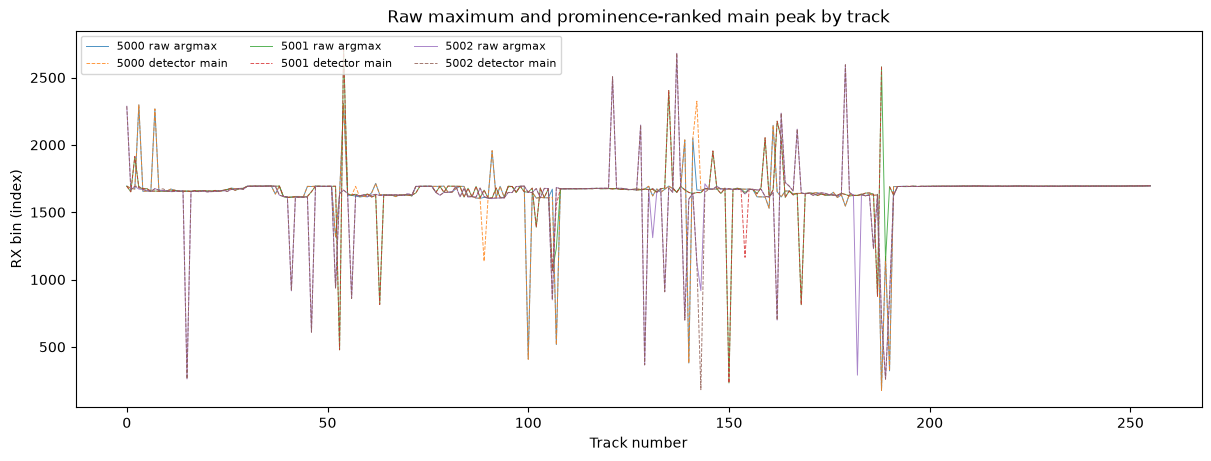

,pulse_index,sweep_num,track_num,component_rank,peak_bin,prominence,rejected_reason
911,1280218,5000,214,4,150.0,405.606131,low_absolute_prominence
912,1280218,5000,214,5,1461.0,380.927126,low_absolute_prominence
913,1280218,5000,214,6,1106.0,377.653171,low_absolute_prominence


In [6]:
fig, ax = plt.subplots(figsize=(12, 4.5), constrained_layout=True)
for sweep in SWEEPS:
    part = pulses[pulses.sweep_num == sweep].sort_values("track_num")
    ax.plot(part.track_num, part.raw_argmax_bin, lw=.7, alpha=.8, label=f"{sweep} raw argmax")
    ax.plot(part.track_num, part.main_peak_bin, lw=.7, alpha=.8, linestyle="--", label=f"{sweep} detector main")
ax.set(xlabel="Track number", ylabel="RX bin (index)", title="Raw maximum and prominence-ranked main peak by track")
ax.legend(ncol=3, fontsize=8)
plt.show()

edge = target_components.loc[~target_components["is_main_component"].astype(bool)
                             & ~target_components["is_valid_secondary_candidate"].astype(bool)]
if len(edge):
    display(edge[["pulse_index", "sweep_num", "track_num", "component_rank", "peak_bin",
                  "prominence", "rejected_reason"]])
else:
    print("No rejected secondary candidates for the selected pulse.")

## Interpretation and limits

The detector emits per-pulse component tables for the specified environment and parameter set. Adjacent-bin peak sensitivity and rejected weak components are visible in the selected pulse. The observed secondary components remain hypotheses from RX waveforms. They need geometry mapping and independent validation before they can be interpreted as 3D returns.